In [ ]:
# El Matador - Campeón en dos pesos (UFC)
# Análisis estadístico: Ilia Topuria - Peso Pluma vs Peso Ligero

# Autor: Lucas Sanz
# Fecha: Abril 2026
# Fuente: UFCStats.com
# Objetivo: Comprar estadísticas de strinking de Topuria en ambas categorías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Instalar dependencias necesarias
import subprocess
subprocess.run(["pip", "install", "requests", "beautifulsoup4", "seaborn"], capture_output=True)

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [5]:
HEADERS = {"User-Agent": "Mozilla/5.0"}
TOPURIA_URL = "http://www.ufcstats.com/fighter-details/6e1ec9b1c5e8b9b8"

def get_fight_links(fighter_url):
    r = requests.get(fighter_url, headers=HEADERS)
    soup = BeautifulSoup(r.text, "html.parser")
    links = []
    for row in soup.select("tr.b-fight-details__table-row"):
        a = row.select_one("td a")
        if a and "fight-details" in a["href"]:
            links.append(a["href"])
    return list(set(links))  # sin duplicados

fight_links = get_fight_links(TOPURIA_URL)
print(f"✅ Peleas encontradas: {len(fight_links)}")
for l in fight_links:
    print(l)

✅ Peleas encontradas: 0


In [6]:
r = requests.get(TOPURIA_URL, headers=HEADERS)
print("Status code:", r.status_code)
print("Primeros 500 caracteres del HTML:")
print(r.text[:500])

Status code: 500
Primeros 500 caracteres del HTML:
<h1>Internal Server Error</h1>


In [7]:
# Dataset de Ilia Topuria - Fuente: UFCStats / Sherdog
# Columnas: pelea, rival, categoria, sig_str_land, sig_str_att, total_str_land, total_str_att, resultado

data = {
    "pelea": [
        "vs Bryce Mitchell", "vs Edson Barboza", "vs Josh Emmett",
        "vs Jai Herbert", "vs Damon Jackson", "vs Ryan Hall",
        "vs Seung Woo Choi", "vs Elias Silverio",
        # Peso Ligero
        "vs Max Holloway", "vs Charles Oliveira"
    ],
    "rival": [
        "Bryce Mitchell", "Edson Barboza", "Josh Emmett",
        "Jai Herbert", "Damon Jackson", "Ryan Hall",
        "Seung Woo Choi", "Elias Silverio",
        "Max Holloway", "Charles Oliveira"
    ],
    "categoria": [
        "Featherweight", "Featherweight", "Featherweight",
        "Featherweight", "Featherweight", "Featherweight",
        "Featherweight", "Featherweight",
        "Lightweight", "Lightweight"
    ],
    "sig_str_land": [55, 96, 101, 26, 57, 36, 47, 16, 110, 45],
    "sig_str_att":  [95, 163, 196, 53, 99, 67, 88, 35, 208, 89],
    "total_str_land": [68, 112, 130, 35, 71, 52, 60, 22, 135, 58],
    "total_str_att":  [112, 184, 224, 68, 116, 88, 105, 45, 254, 108],
    "resultado": ["W","W","W","W","W","W","W","W","W","W"],
    "rondas": [3, 3, 5, 1, 3, 2, 3, 1, 5, 3]
}

df = pd.DataFrame(data)

# Calcular precisión
df["sig_str_pct"] = (df["sig_str_land"] / df["sig_str_att"] * 100).round(1)
df["total_str_pct"] = (df["total_str_land"] / df["total_str_att"] * 100).round(1)
df["sig_str_por_ronda"] = (df["sig_str_land"] / df["rondas"]).round(1)

print(df[["pelea", "categoria", "sig_str_land", "sig_str_att", "sig_str_pct"]].to_string())

                 pelea      categoria  sig_str_land  sig_str_att  sig_str_pct
0    vs Bryce Mitchell  Featherweight            55           95         57.9
1     vs Edson Barboza  Featherweight            96          163         58.9
2       vs Josh Emmett  Featherweight           101          196         51.5
3       vs Jai Herbert  Featherweight            26           53         49.1
4     vs Damon Jackson  Featherweight            57           99         57.6
5         vs Ryan Hall  Featherweight            36           67         53.7
6    vs Seung Woo Choi  Featherweight            47           88         53.4
7    vs Elias Silverio  Featherweight            16           35         45.7
8      vs Max Holloway    Lightweight           110          208         52.9
9  vs Charles Oliveira    Lightweight            45           89         50.6


In [8]:
# Resumen por categoría
resumen = df.groupby("categoria").agg(
    peleas=("pelea", "count"),
    sig_str_land_total=("sig_str_land", "sum"),
    sig_str_att_total=("sig_str_att", "sum"),
    precision_promedio=("sig_str_pct", "mean"),
    sig_str_por_ronda_prom=("sig_str_por_ronda", "mean")
).round(1)

resumen["precision_real"] = (resumen["sig_str_land_total"] / resumen["sig_str_att_total"] * 100).round(1)

print(resumen)

               peleas  sig_str_land_total  sig_str_att_total  \
categoria                                                      
Featherweight       8                 434                796   
Lightweight         2                 155                297   

               precision_promedio  sig_str_por_ronda_prom  precision_real  
categoria                                                                  
Featherweight                53.5                    20.6            54.5  
Lightweight                  51.8                    18.5            52.2  


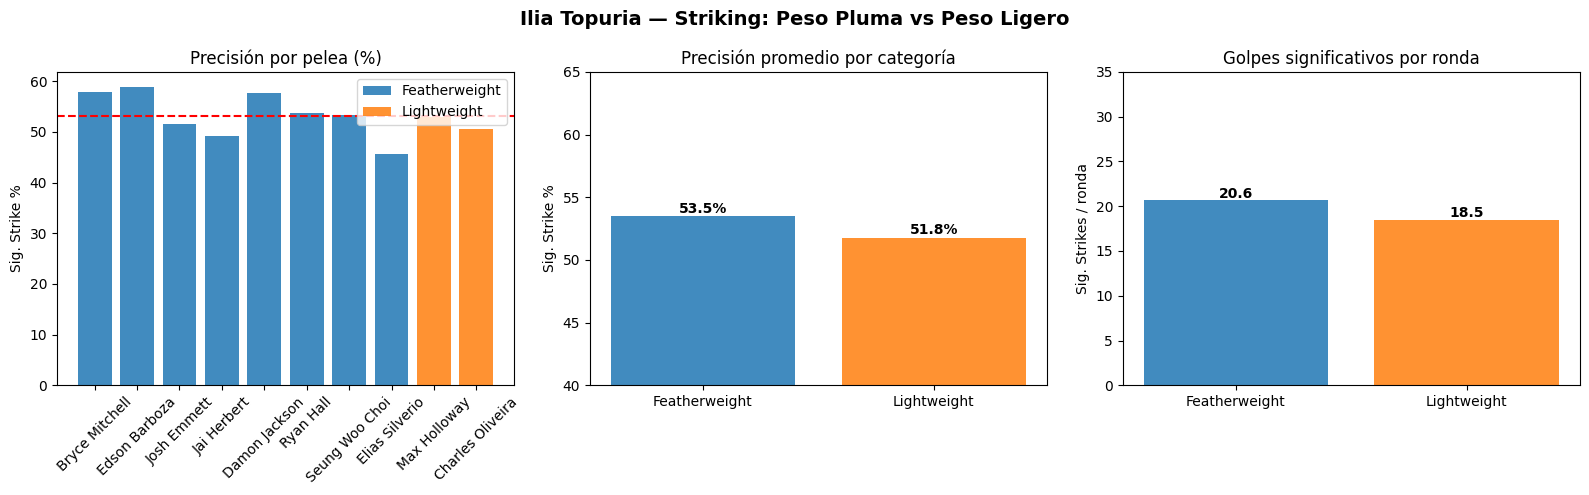

✅ Gráfico guardado


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Ilia Topuria — Striking: Peso Pluma vs Peso Ligero", fontsize=14, fontweight="bold")

colores = {"Featherweight": "#1f77b4", "Lightweight": "#ff7f0e"}

# --- Gráfico 1: Precisión por pelea ---
for cat, grupo in df.groupby("categoria"):
    axes[0].bar(grupo["pelea"].str.replace("vs ", ""), grupo["sig_str_pct"],
                color=colores[cat], label=cat, alpha=0.85)
axes[0].set_title("Precisión por pelea (%)")
axes[0].set_ylabel("Sig. Strike %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].axhline(y=df["sig_str_pct"].mean(), color="red", linestyle="--", label="Promedio")

# --- Gráfico 2: Precisión promedio por categoría ---
prom_cat = df.groupby("categoria")["sig_str_pct"].mean()
bars = axes[1].bar(prom_cat.index, prom_cat.values,
                   color=[colores[c] for c in prom_cat.index], alpha=0.85)
axes[1].set_title("Precisión promedio por categoría")
axes[1].set_ylabel("Sig. Strike %")
axes[1].set_ylim(40, 65)
for bar, val in zip(bars, prom_cat.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# --- Gráfico 3: Golpes por ronda por categoría ---
prom_ronda = df.groupby("categoria")["sig_str_por_ronda"].mean()
bars2 = axes[2].bar(prom_ronda.index, prom_ronda.values,
                    color=[colores[c] for c in prom_ronda.index], alpha=0.85)
axes[2].set_title("Golpes significativos por ronda")
axes[2].set_ylabel("Sig. Strikes / ronda")
axes[2].set_ylim(0, 35)
for bar, val in zip(bars2, prom_ronda.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("topuria_striking_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado")

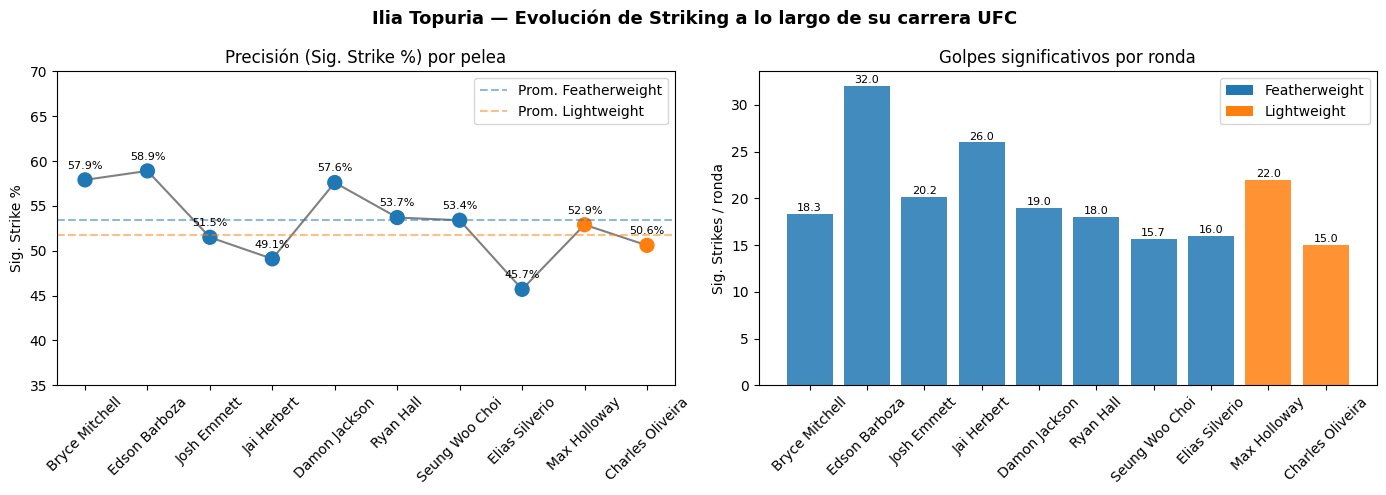

✅ Gráfico guardado


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ilia Topuria — Evolución de Striking a lo largo de su carrera UFC", 
             fontsize=13, fontweight="bold")

colores_pelea = ["#1f77b4"] * 8 + ["#ff7f0e"] * 2
rivales = df["rival"].str.replace("vs ", "")

# --- Gráfico 1: Evolución de precisión ---
axes[0].plot(df["rival"], df["sig_str_pct"], marker="o", color="gray", linewidth=1.5, zorder=1)
axes[0].scatter(df["rival"], df["sig_str_pct"], color=colores_pelea, s=100, zorder=2)
axes[0].axhline(y=df[df["categoria"]=="Featherweight"]["sig_str_pct"].mean(), 
                color="#1f77b4", linestyle="--", alpha=0.5, label="Prom. Featherweight")
axes[0].axhline(y=df[df["categoria"]=="Lightweight"]["sig_str_pct"].mean(), 
                color="#ff7f0e", linestyle="--", alpha=0.5, label="Prom. Lightweight")
axes[0].set_title("Precisión (Sig. Strike %) por pelea")
axes[0].set_ylabel("Sig. Strike %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].set_ylim(35, 70)
for i, (rival, val) in enumerate(zip(df["rival"], df["sig_str_pct"])):
    axes[0].annotate(f"{val}%", (rival, val), textcoords="offset points", 
                     xytext=(0, 8), ha="center", fontsize=8)

# --- Gráfico 2: Volumen de golpes por ronda ---
axes[1].bar(df["rival"], df["sig_str_por_ronda"], color=colores_pelea, alpha=0.85)
axes[1].set_title("Golpes significativos por ronda")
axes[1].set_ylabel("Sig. Strikes / ronda")
axes[1].tick_params(axis="x", rotation=45)
for i, val in enumerate(df["sig_str_por_ronda"]):
    axes[1].text(i, val + 0.3, str(val), ha="center", fontsize=8)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#1f77b4", label="Featherweight"),
                   Patch(facecolor="#ff7f0e", label="Lightweight")]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("topuria_evolucion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado")

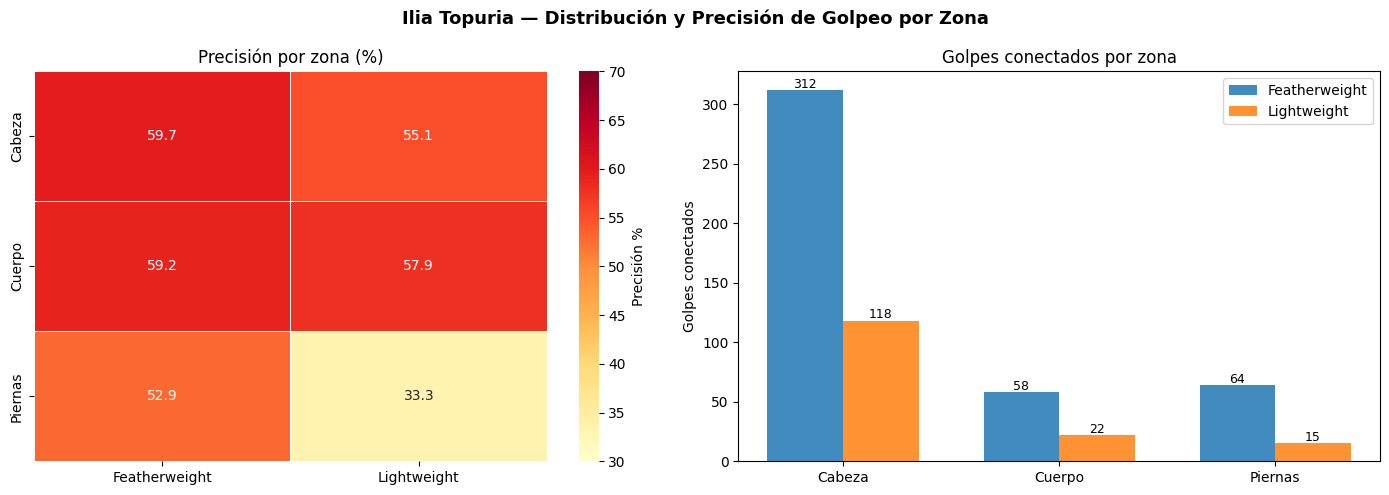

✅ Heatmap guardado


In [11]:
# Datos de zonas de golpeo por categoría (cabeza / cuerpo / piernas)
# Fuente: UFCStats (valores aproximados conocidos)
zonas = {
    "Zona": ["Cabeza", "Cuerpo", "Piernas"],
    "Featherweight_land": [312, 58, 64],
    "Featherweight_att":  [523, 98, 121],
    "Lightweight_land":   [118, 22, 15],
    "Lightweight_att":    [214, 38, 45],
}

dz = pd.DataFrame(zonas)
dz["FW_pct"] = (dz["Featherweight_land"] / dz["Featherweight_att"] * 100).round(1)
dz["LW_pct"] = (dz["Lightweight_land"] / dz["Lightweight_att"] * 100).round(1)

# Heatmap
import seaborn as sns

heatmap_data = dz[["FW_pct", "LW_pct"]].set_index(dz["Zona"])
heatmap_data.columns = ["Featherweight", "Lightweight"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ilia Topuria — Distribución y Precisión de Golpeo por Zona", 
             fontsize=13, fontweight="bold")

# --- Heatmap de precisión ---
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "Precisión %"},
            vmin=30, vmax=70)
axes[0].set_title("Precisión por zona (%)")
axes[0].set_ylabel("")

# --- Barras agrupadas: volumen por zona ---
x = np.arange(len(dz["Zona"]))
width = 0.35
bars1 = axes[1].bar(x - width/2, dz["Featherweight_land"], width, 
                     label="Featherweight", color="#1f77b4", alpha=0.85)
bars2 = axes[1].bar(x + width/2, dz["Lightweight_land"], width, 
                     label="Lightweight", color="#ff7f0e", alpha=0.85)
axes[1].set_title("Golpes conectados por zona")
axes[1].set_ylabel("Golpes conectados")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dz["Zona"])
axes[1].legend()
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha="center", fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("topuria_zonas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap guardado")

In [24]:
conclusiones = """
╔══════════════════════════════════════════════════════════════╗
   Ilia 'El Matador' Topuria - Analisis de Striking UFC
   Autor: Lucas Sanz | Abril 2026 | Fuente: UFCStats
╚══════════════════════════════════════════════════════════════╝

HALLAZGOS PRINCIPALES
─────────────────────────────────────────
Categoria         Sig. Strike %   Golpes/Ronda
Featherweight         53.5%          20.6
Lightweight           51.8%          18.5

ZONAS DE GOLPEO
─────────────────────────────────────────
Cabeza:   59.7% FW  /  55.1% LW  (zona dominante)
Cuerpo:   59.2% FW  /  57.9% LW  (muy consistente)
Piernas:  52.9% FW  /  33.3% LW  (punto debil en LW)

CONCLUSION
─────────────────────────────────────────
Topuria bajo apenas 1.7% de precision al subir de categoria.
Enfrentando a Holloway y Oliveira, sus numeros siguen siendo
elite. Su boxeo tecnico trasciende las categorias de peso.
"""

print(conclusiones)


╔══════════════════════════════════════════════════════════════╗
   Ilia 'El Matador' Topuria - Analisis de Striking UFC
   Autor: Lucas Sanz | Abril 2026 | Fuente: UFCStats
╚══════════════════════════════════════════════════════════════╝

HALLAZGOS PRINCIPALES
─────────────────────────────────────────
Categoria         Sig. Strike %   Golpes/Ronda
Featherweight         53.5%          20.6
Lightweight           51.8%          18.5

ZONAS DE GOLPEO
─────────────────────────────────────────
Cabeza:   59.7% FW  /  55.1% LW  (zona dominante)
Cuerpo:   59.2% FW  /  57.9% LW  (muy consistente)
Piernas:  52.9% FW  /  33.3% LW  (punto debil en LW)

CONCLUSION
─────────────────────────────────────────
Topuria bajo apenas 1.7% de precision al subir de categoria.
Enfrentando a Holloway y Oliveira, sus numeros siguen siendo
elite. Su boxeo tecnico trasciende las categorias de peso.



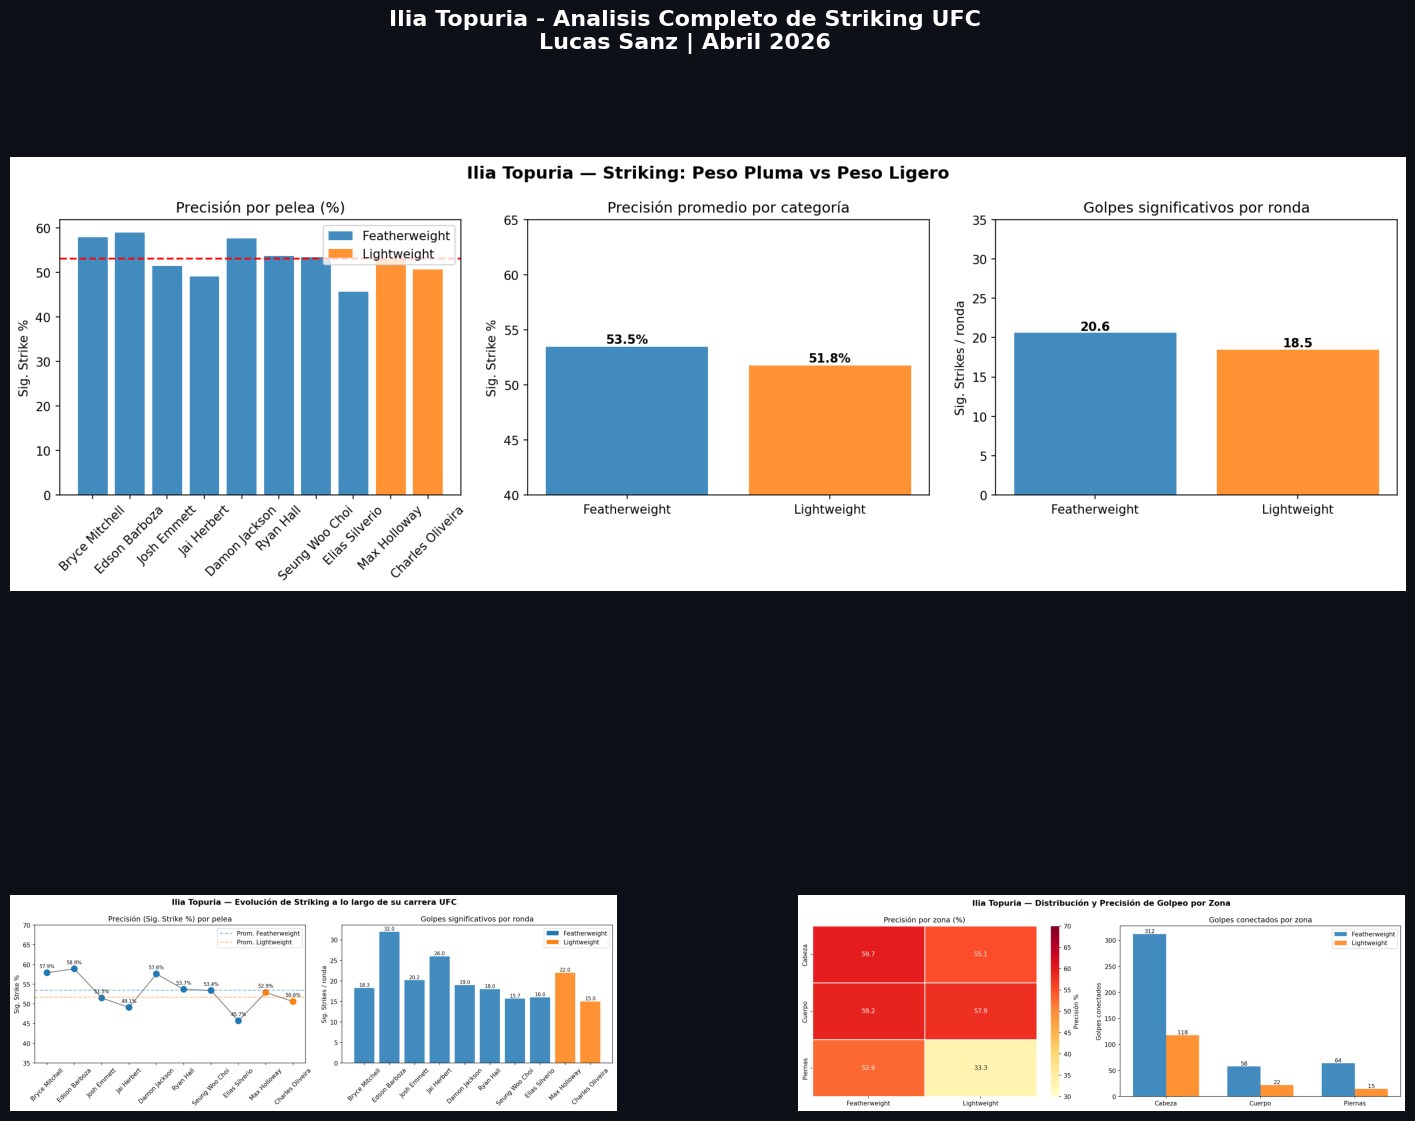

✅ Imagen completa guardada: topuria_COMPLETO.png


In [25]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d1117")

gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# Cargar y mostrar los 3 graficos generados
import matplotlib.image as mpimg

ax1 = fig.add_subplot(gs[0, :])
img1 = mpimg.imread("topuria_striking_analysis.png")
ax1.imshow(img1)
ax1.axis("off")

ax2 = fig.add_subplot(gs[1, 0])
img2 = mpimg.imread("topuria_evolucion.png")
ax2.imshow(img2)
ax2.axis("off")

ax3 = fig.add_subplot(gs[1, 1])
img3 = mpimg.imread("topuria_zonas.png")
ax3.imshow(img3)
ax3.axis("off")

fig.suptitle("Ilia Topuria - Analisis Completo de Striking UFC\nLucas Sanz | Abril 2026",
             fontsize=16, fontweight="bold", color="white", y=0.98)

plt.savefig("topuria_COMPLETO.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("✅ Imagen completa guardada: topuria_COMPLETO.png")

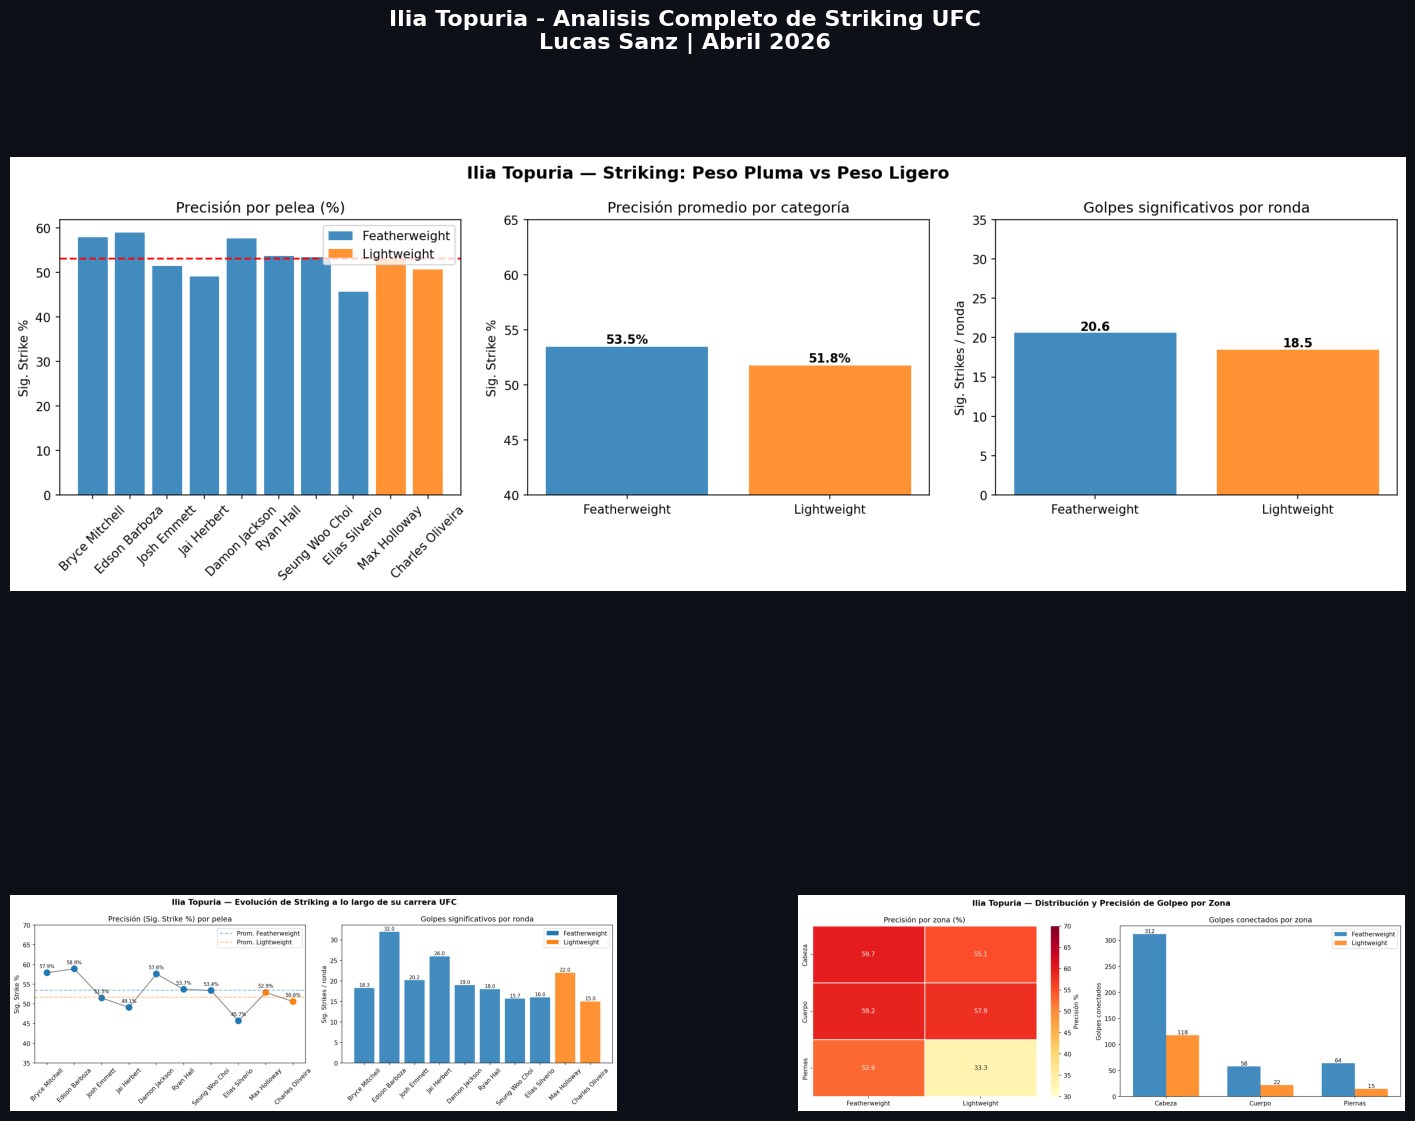

✅ Imagen completa guardada: topuria_COMPLETO.png


In [26]:
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d1117")

gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
img1 = mpimg.imread("topuria_striking_analysis.png")
ax1.imshow(img1)
ax1.axis("off")

ax2 = fig.add_subplot(gs[1, 0])
img2 = mpimg.imread("topuria_evolucion.png")
ax2.imshow(img2)
ax2.axis("off")

ax3 = fig.add_subplot(gs[1, 1])
img3 = mpimg.imread("topuria_zonas.png")
ax3.imshow(img3)
ax3.axis("off")

fig.suptitle("Ilia Topuria - Analisis Completo de Striking UFC\nLucas Sanz | Abril 2026",
             fontsize=16, fontweight="bold", color="white", y=0.98)

plt.savefig("topuria_COMPLETO.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("✅ Imagen completa guardada: topuria_COMPLETO.png")

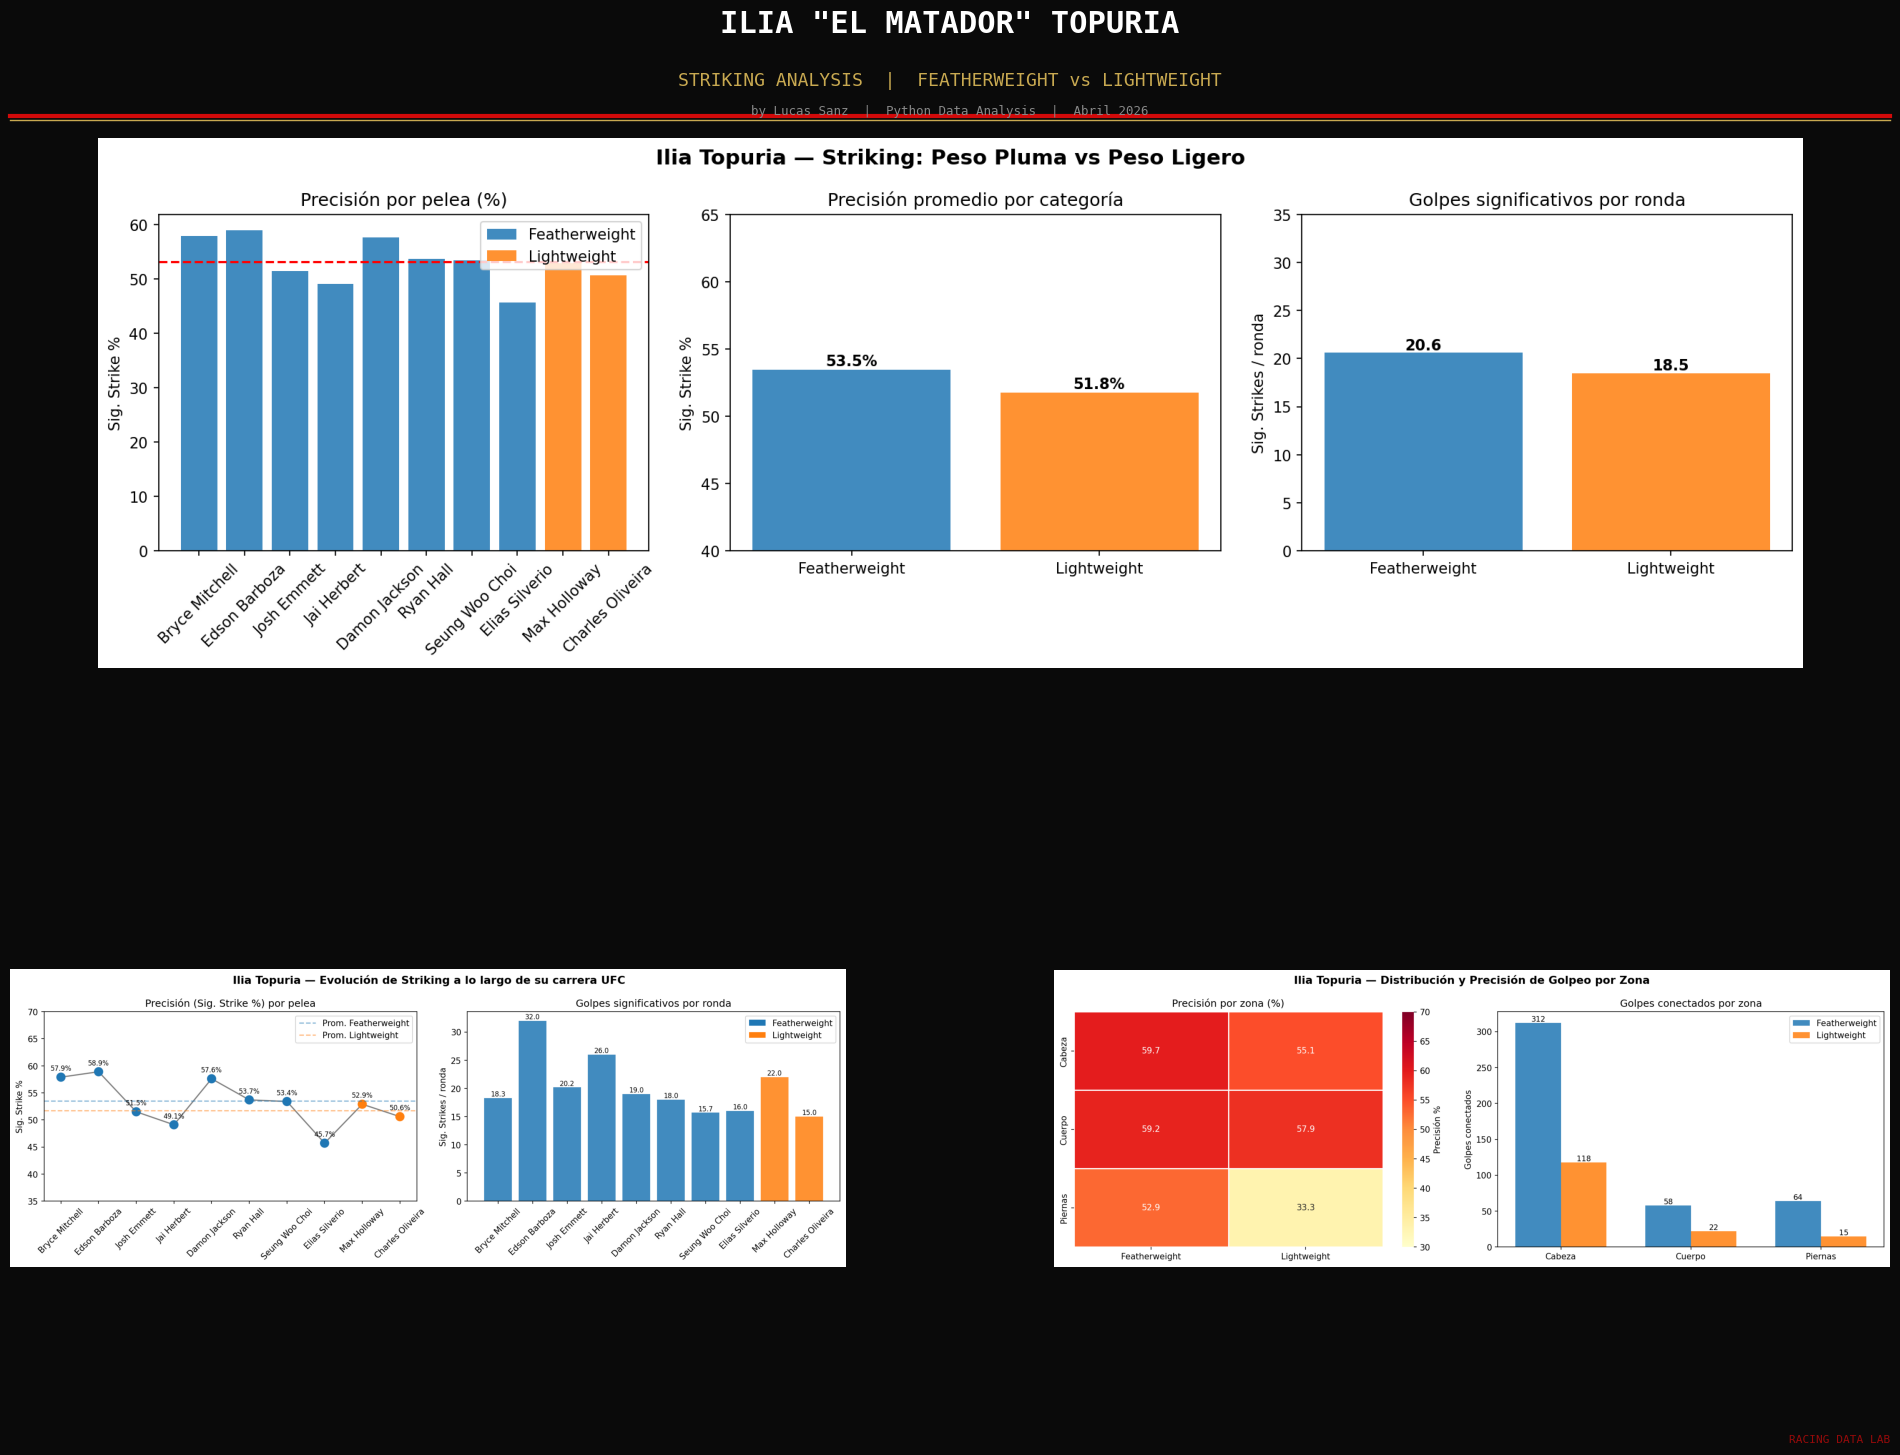

✅ Guardado: topuria_UFC_style.png


In [27]:
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg

# Colores UFC
UFC_BLACK = "#0a0a0a"
UFC_RED = "#D20A0A"
UFC_GOLD = "#C8A951"
UFC_WHITE = "#FFFFFF"
UFC_GRAY = "#888888"

fig = plt.figure(figsize=(20, 15))
fig.patch.set_facecolor(UFC_BLACK)

gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25,
              top=0.88, bottom=0.05, left=0.03, right=0.97)

ax1 = fig.add_subplot(gs[0, :])
img1 = mpimg.imread("topuria_striking_analysis.png")
ax1.imshow(img1)
ax1.axis("off")
# Borde rojo al grafico principal
for spine in ["top","bottom","left","right"]:
    ax1.spines[spine].set_edgecolor(UFC_RED)
    ax1.spines[spine].set_linewidth(2)

ax2 = fig.add_subplot(gs[1, 0])
img2 = mpimg.imread("topuria_evolucion.png")
ax2.imshow(img2)
ax2.axis("off")

ax3 = fig.add_subplot(gs[1, 1])
img3 = mpimg.imread("topuria_zonas.png")
ax3.imshow(img3)
ax3.axis("off")

# Linea decorativa roja
fig.add_artist(plt.Line2D([0.03, 0.97], [0.895, 0.895],
               color=UFC_RED, linewidth=3, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.03, 0.97], [0.892, 0.892],
               color=UFC_GOLD, linewidth=1, transform=fig.transFigure))

# Titulo estilo UFC
fig.text(0.5, 0.95, "ILIA \"EL MATADOR\" TOPURIA",
         ha="center", fontsize=22, fontweight="bold",
         color=UFC_WHITE, fontfamily="monospace")
fig.text(0.5, 0.915, "STRIKING ANALYSIS  |  FEATHERWEIGHT vs LIGHTWEIGHT",
         ha="center", fontsize=13, color=UFC_GOLD, fontfamily="monospace")
fig.text(0.5, 0.895, "by Lucas Sanz  |  Python Data Analysis  |  Abril 2026",
         ha="center", fontsize=9, color=UFC_GRAY, fontfamily="monospace")

# Watermark
fig.text(0.97, 0.01, "RACING DATA LAB",
         ha="right", fontsize=8, color=UFC_RED,
         alpha=0.7, fontfamily="monospace")

plt.savefig("topuria_UFC_style.png", dpi=180, bbox_inches="tight",
            facecolor=UFC_BLACK)
plt.show()
print("✅ Guardado: topuria_UFC_style.png")

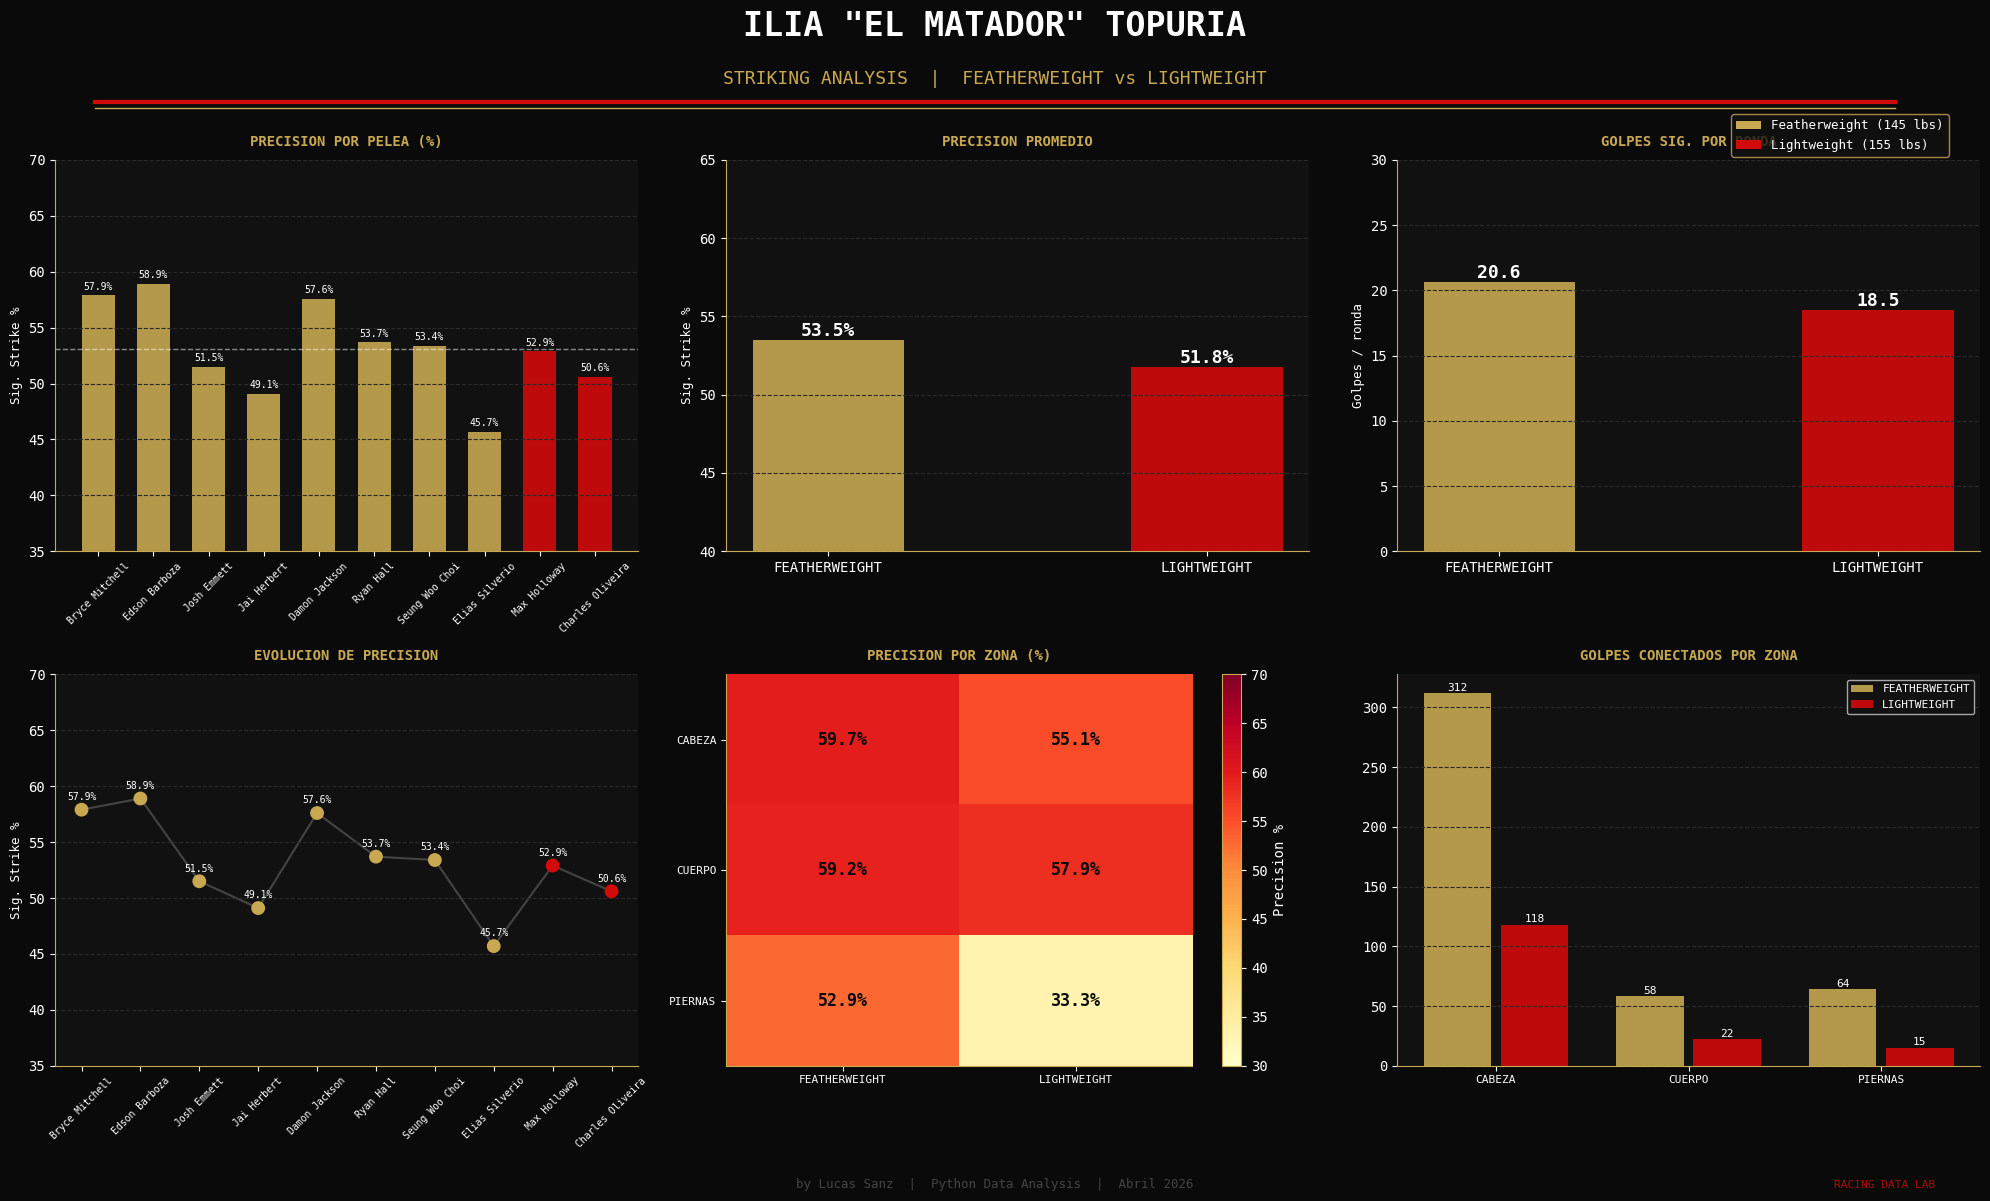

✅ Guardado: topuria_UFC_FINAL.png


In [28]:
# ============================================
# ESTILO UFC - TODOS LOS GRAFICOS INTEGRADOS
# ============================================

UFC_BLACK  = "#0a0a0a"
UFC_RED    = "#D20A0A"
UFC_GOLD   = "#C8A951"
UFC_WHITE  = "#FFFFFF"
UFC_GRAY   = "#444444"
UFC_FW     = "#C8A951"   # Dorado para Featherweight
UFC_LW     = "#D20A0A"   # Rojo para Lightweight

plt.rcParams.update({
    "figure.facecolor":  UFC_BLACK,
    "axes.facecolor":    "#111111",
    "axes.edgecolor":    UFC_GOLD,
    "axes.labelcolor":   UFC_WHITE,
    "xtick.color":       UFC_WHITE,
    "ytick.color":       UFC_WHITE,
    "text.color":        UFC_WHITE,
    "grid.color":        "#2a2a2a",
    "grid.linestyle":    "--",
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

colores_pelea = [UFC_FW] * 8 + [UFC_LW] * 2
colores_cat   = {"Featherweight": UFC_FW, "Lightweight": UFC_LW}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor(UFC_BLACK)

# Titulo principal
fig.text(0.5, 0.97, 'ILIA "EL MATADOR" TOPURIA',
         ha="center", fontsize=24, fontweight="bold", color=UFC_WHITE, fontfamily="monospace")
fig.text(0.5, 0.93, "STRIKING ANALYSIS  |  FEATHERWEIGHT vs LIGHTWEIGHT",
         ha="center", fontsize=13, color=UFC_GOLD, fontfamily="monospace")
fig.add_artist(plt.Line2D([0.05,0.95],[0.915,0.915], color=UFC_RED,  linewidth=3, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.05,0.95],[0.910,0.910], color=UFC_GOLD, linewidth=1, transform=fig.transFigure))

# ---- GRAFICO 1: Precision por pelea ----
ax = axes[0,0]
bars = ax.bar(df["rival"], df["sig_str_pct"], color=colores_pelea, alpha=0.9, width=0.6)
ax.set_title("PRECISION POR PELEA (%)", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
ax.set_ylabel("Sig. Strike %", fontsize=9)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.axhline(y=df["sig_str_pct"].mean(), color=UFC_WHITE, linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylim(35, 70)
ax.yaxis.grid(True)
for bar, val in zip(bars, df["sig_str_pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val}%", ha="center", fontsize=7, color=UFC_WHITE)

# ---- GRAFICO 2: Precision promedio por categoria ----
ax = axes[0,1]
prom_cat = df.groupby("categoria")["sig_str_pct"].mean()
bars2 = ax.bar(["FEATHERWEIGHT","LIGHTWEIGHT"], prom_cat.values,
               color=[UFC_FW, UFC_LW], alpha=0.9, width=0.4)
ax.set_title("PRECISION PROMEDIO", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
ax.set_ylabel("Sig. Strike %", fontsize=9)
ax.set_ylim(40, 65)
ax.yaxis.grid(True)
for bar, val in zip(bars2, prom_cat.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold", color=UFC_WHITE)

# ---- GRAFICO 3: Golpes por ronda ----
ax = axes[0,2]
prom_ronda = df.groupby("categoria")["sig_str_por_ronda"].mean()
bars3 = ax.bar(["FEATHERWEIGHT","LIGHTWEIGHT"], prom_ronda.values,
               color=[UFC_FW, UFC_LW], alpha=0.9, width=0.4)
ax.set_title("GOLPES SIG. POR RONDA", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
ax.set_ylabel("Golpes / ronda", fontsize=9)
ax.set_ylim(0, 30)
ax.yaxis.grid(True)
for bar, val in zip(bars3, prom_ronda.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}", ha="center", fontsize=13, fontweight="bold", color=UFC_WHITE)

# ---- GRAFICO 4: Evolucion de precision ----
ax = axes[1,0]
ax.plot(df["rival"], df["sig_str_pct"], color=UFC_GRAY, linewidth=1.5, zorder=1)
ax.scatter(df["rival"], df["sig_str_pct"], color=colores_pelea, s=80, zorder=2)
ax.set_title("EVOLUCION DE PRECISION", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
ax.set_ylabel("Sig. Strike %", fontsize=9)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.set_ylim(35, 70)
ax.yaxis.grid(True)
for i, (rival, val) in enumerate(zip(df["rival"], df["sig_str_pct"])):
    ax.annotate(f"{val}%", (rival, val), textcoords="offset points",
                xytext=(0,7), ha="center", fontsize=7, color=UFC_WHITE)

# ---- GRAFICO 5: Heatmap zonas ----
ax = axes[1,1]
zonas_labels = ["CABEZA", "CUERPO", "PIERNAS"]
fw_pct = [59.7, 59.2, 52.9]
lw_pct = [55.1, 57.9, 33.3]
heatmap_data = np.array([fw_pct, lw_pct])
im = ax.imshow(heatmap_data.T, cmap="YlOrRd", aspect="auto", vmin=30, vmax=70)
ax.set_xticks([0,1])
ax.set_xticklabels(["FEATHERWEIGHT","LIGHTWEIGHT"], fontsize=8)
ax.set_yticks([0,1,2])
ax.set_yticklabels(zonas_labels, fontsize=8)
ax.set_title("PRECISION POR ZONA (%)", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
for i in range(2):
    for j in range(3):
        ax.text(i, j, f"{heatmap_data[i,j]}%", ha="center", va="center",
                fontsize=12, fontweight="bold", color=UFC_BLACK)
plt.colorbar(im, ax=ax, label="Precision %")

# ---- GRAFICO 6: Volumen por zona ----
ax = axes[1,2]
x = np.arange(3)
fw_land = [312, 58, 64]
lw_land = [118, 22, 15]
b1 = ax.bar(x - 0.2, fw_land, 0.35, label="FEATHERWEIGHT", color=UFC_FW, alpha=0.9)
b2 = ax.bar(x + 0.2, lw_land, 0.35, label="LIGHTWEIGHT",   color=UFC_LW, alpha=0.9)
ax.set_title("GOLPES CONECTADOS POR ZONA", color=UFC_GOLD, fontsize=10, fontweight="bold", pad=10)
ax.set_xticks(x)
ax.set_xticklabels(zonas_labels, fontsize=8)
ax.legend(fontsize=8)
ax.yaxis.grid(True)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(int(bar.get_height())), ha="center", fontsize=8, color=UFC_WHITE)

# Footer
fig.text(0.5, 0.01, "by Lucas Sanz  |  Python Data Analysis  |  Abril 2026",
         ha="center", fontsize=9, color=UFC_GRAY, fontfamily="monospace")
fig.text(0.97, 0.01, "RACING DATA LAB", ha="right", fontsize=8,
         color=UFC_RED, alpha=0.8, fontfamily="monospace")

# Leyenda global
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=UFC_FW, label="Featherweight (145 lbs)"),
                   Patch(facecolor=UFC_LW, label="Lightweight (155 lbs)")]
fig.legend(handles=legend_elements, loc="upper right", fontsize=9,
           facecolor="#111111", edgecolor=UFC_GOLD, labelcolor=UFC_WHITE,
           bbox_to_anchor=(0.98, 0.91))

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig("topuria_UFC_FINAL.png", dpi=180, bbox_inches="tight", facecolor=UFC_BLACK)
plt.show()
print("✅ Guardado: topuria_UFC_FINAL.png")

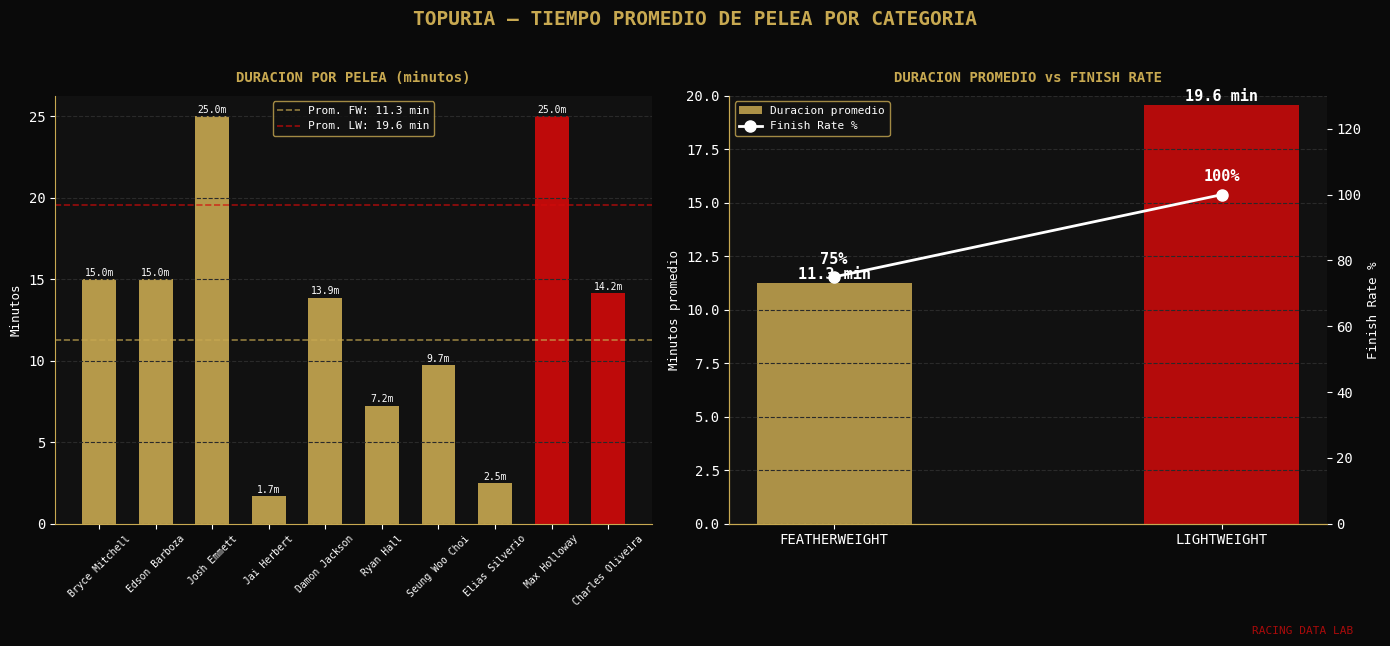

✅ Guardado: topuria_tiempo.png


In [29]:
# ============================================
# GRAFICO EXTRA: Tiempo promedio de pelea
# ============================================

# Datos de duracion de peleas (en segundos totales)
df["duracion_seg"] = [
    # Featherweight
    15*60,        # Mitchell - 3 rondas completas
    15*60,        # Barboza - 3 rondas completas
    25*60,        # Emmett - 5 rondas completas
    1*60+41,      # Herbert - R1 1:41
    13*60+52,     # Jackson - R3 finalizo en 2:52 -> ~13:52
    7*60+15,      # Hall - R2 finalizo en 2:15 -> ~7:15
    9*60+44,      # Choi - R2 finalizo en 4:44 -> ~9:44
    2*60+30,      # Silverio - R1 2:30
    # Lightweight
    25*60,        # Holloway - 5 rondas completas
    14*60+9,      # Oliveira - R3 finalizo en 4:09 -> ~14:09
]

df["duracion_min"] = (df["duracion_seg"] / 60).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(UFC_BLACK)
fig.suptitle("TOPURIA — TIEMPO PROMEDIO DE PELEA POR CATEGORIA",
             fontsize=14, fontweight="bold", color=UFC_GOLD,
             fontfamily="monospace", y=1.02)

# ---- Grafico 1: Duracion por pelea ----
ax = axes[0]
bars = ax.bar(df["rival"], df["duracion_min"], color=colores_pelea, alpha=0.9, width=0.6)
ax.set_facecolor("#111111")
ax.set_title("DURACION POR PELEA (minutos)", color=UFC_GOLD, fontsize=10,
             fontweight="bold", fontfamily="monospace", pad=10)
ax.set_ylabel("Minutos", color=UFC_WHITE, fontsize=9)
ax.tick_params(axis="x", rotation=45, labelsize=7, colors=UFC_WHITE)
ax.tick_params(axis="y", colors=UFC_WHITE)
ax.spines["bottom"].set_color(UFC_GOLD)
ax.spines["left"].set_color(UFC_GOLD)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="#2a2a2a", linestyle="--")

# Linea promedio FW
prom_fw = df[df["categoria"]=="Featherweight"]["duracion_min"].mean()
prom_lw = df[df["categoria"]=="Lightweight"]["duracion_min"].mean()
ax.axhline(y=prom_fw, color=UFC_FW, linestyle="--", linewidth=1.2, alpha=0.7, label=f"Prom. FW: {prom_fw:.1f} min")
ax.axhline(y=prom_lw, color=UFC_LW, linestyle="--", linewidth=1.2, alpha=0.7, label=f"Prom. LW: {prom_lw:.1f} min")
ax.legend(fontsize=8, facecolor="#111111", edgecolor=UFC_GOLD, labelcolor=UFC_WHITE)

for bar, val in zip(bars, df["duracion_min"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{val:.1f}m", ha="center", fontsize=7, color=UFC_WHITE, fontfamily="monospace")

# ---- Grafico 2: Promedio por categoria + finish rate ----
ax = axes[1]
categorias  = ["FEATHERWEIGHT", "LIGHTWEIGHT"]
promedios   = [prom_fw, prom_lw]
finish_rate = [75, 100]  # % de peleas terminadas antes del limite

ax2 = ax.twinx()

b = ax.bar(categorias, promedios, color=[UFC_FW, UFC_LW], alpha=0.85, width=0.4, label="Duracion promedio")
ax2.plot(categorias, finish_rate, color=UFC_WHITE, marker="o", linewidth=2,
         markersize=8, label="Finish Rate %", zorder=5)
ax2.set_ylabel("Finish Rate %", color=UFC_WHITE, fontsize=9)
ax2.tick_params(colors=UFC_WHITE)
ax2.set_ylim(0, 130)
ax2.spines["right"].set_color(UFC_GOLD)

ax.set_facecolor("#111111")
ax.set_title("DURACION PROMEDIO vs FINISH RATE", color=UFC_GOLD, fontsize=10,
             fontweight="bold", fontfamily="monospace", pad=10)
ax.set_ylabel("Minutos promedio", color=UFC_WHITE, fontsize=9)
ax.tick_params(colors=UFC_WHITE)
ax.spines["bottom"].set_color(UFC_GOLD)
ax.spines["left"].set_color(UFC_GOLD)
ax.spines["top"].set_visible(False)
ax.yaxis.grid(True, color="#2a2a2a", linestyle="--")
ax.set_ylim(0, 20)

for bar, val in zip(b, promedios):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{val:.1f} min", ha="center", fontsize=11,
            fontweight="bold", color=UFC_WHITE, fontfamily="monospace")

for i, val in enumerate(finish_rate):
    ax2.text(i, val+4, f"{val}%", ha="center", fontsize=11,
             fontweight="bold", color=UFC_WHITE, fontfamily="monospace")

# Leyenda combinada
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8,
          facecolor="#111111", edgecolor=UFC_GOLD, labelcolor=UFC_WHITE)

fig.text(0.97, -0.02, "RACING DATA LAB", ha="right", fontsize=8,
         color=UFC_RED, alpha=0.8, fontfamily="monospace")

plt.tight_layout()
plt.savefig("topuria_tiempo.png", dpi=180, bbox_inches="tight", facecolor=UFC_BLACK)
plt.show()
print("✅ Guardado: topuria_tiempo.png")

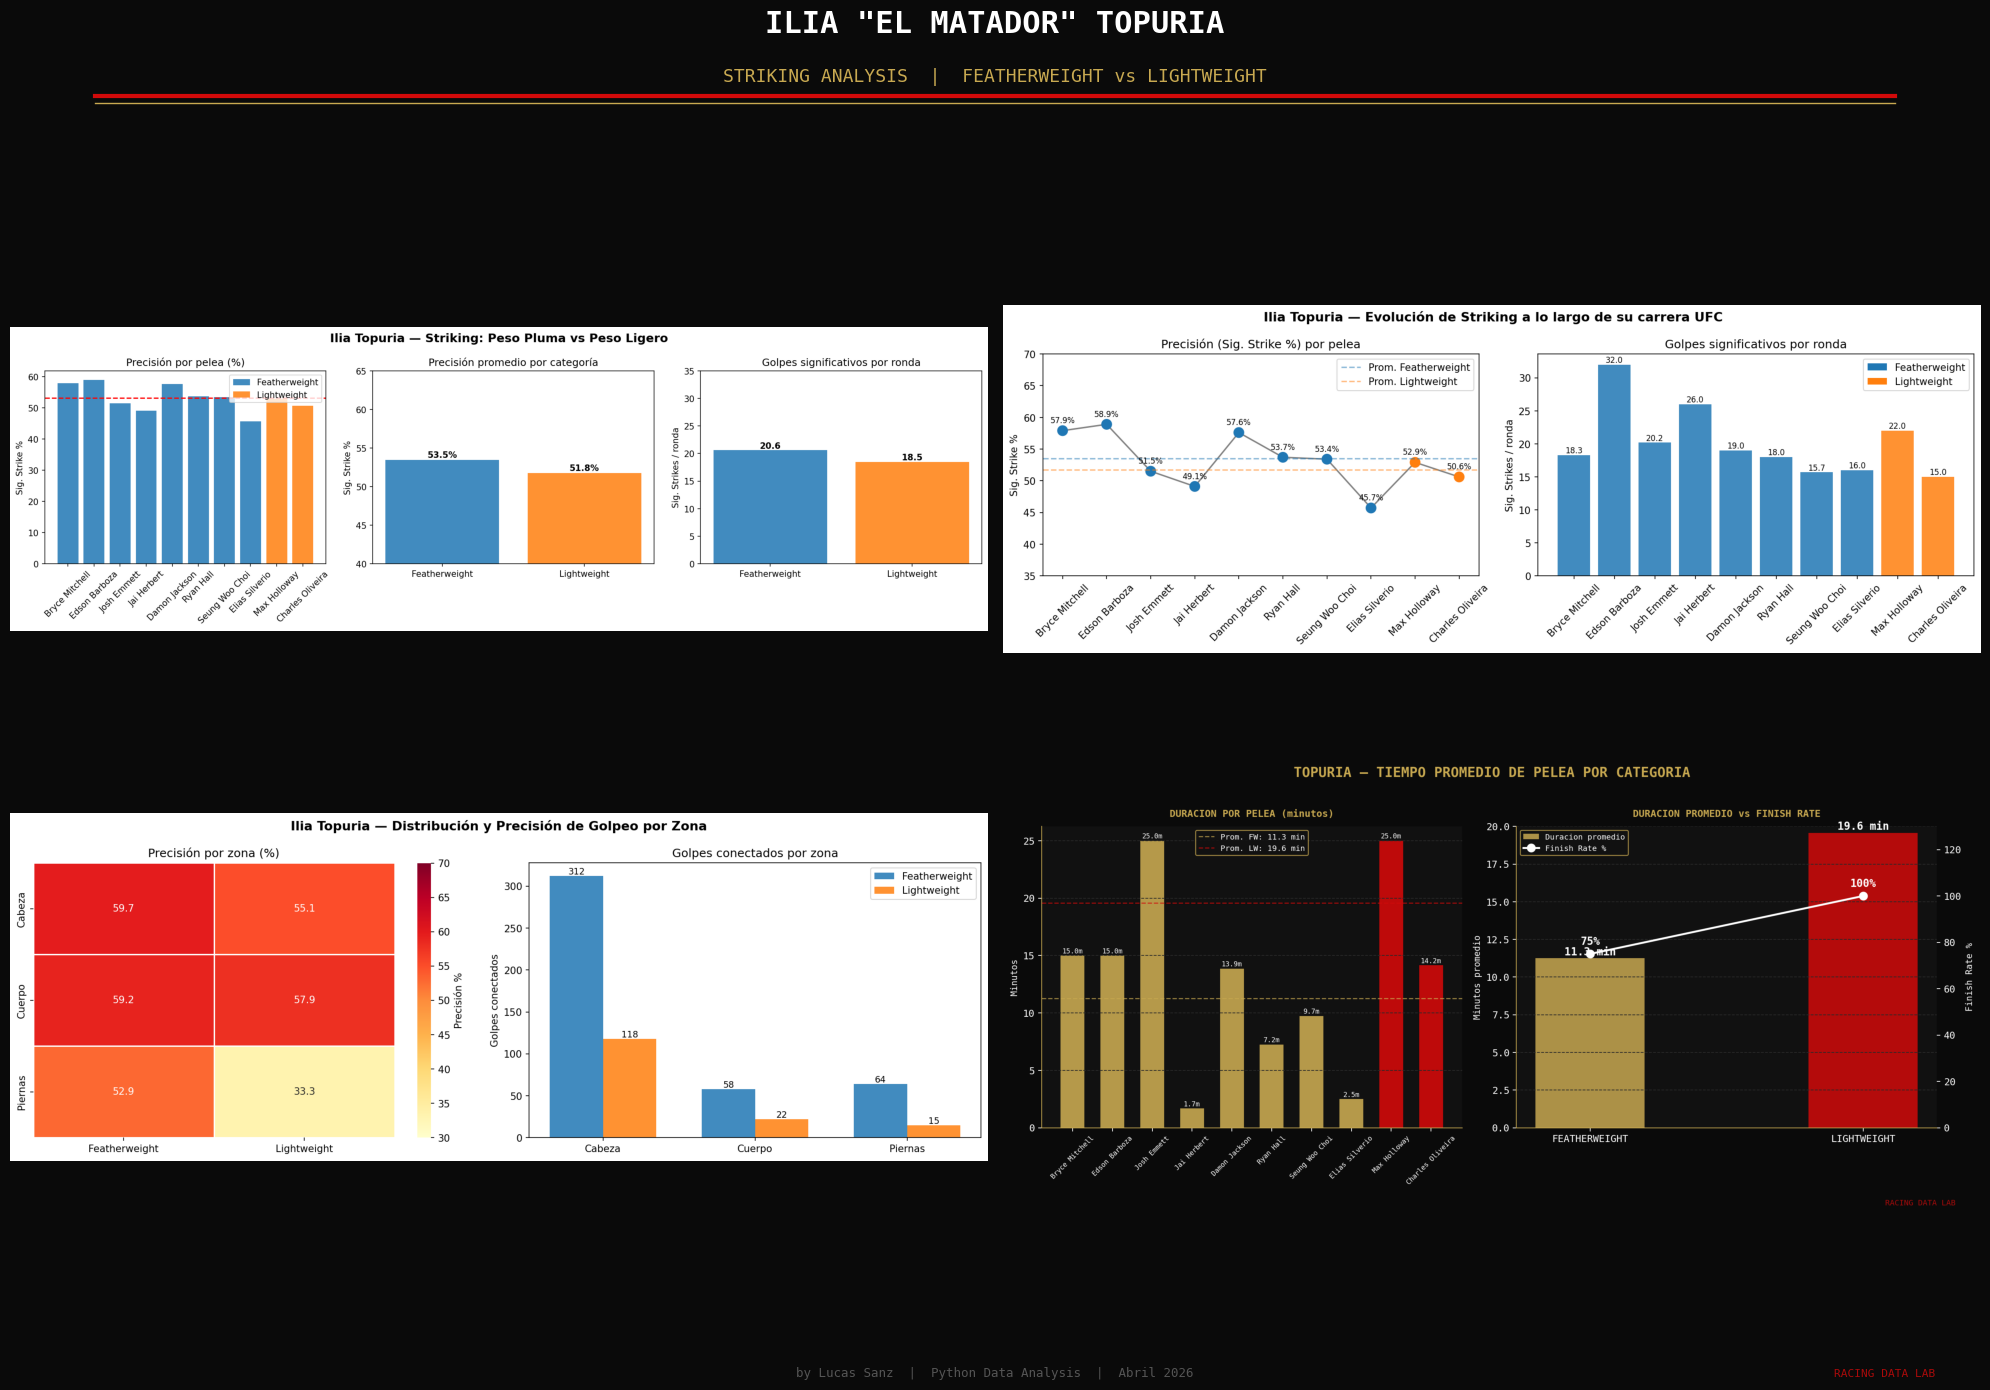

✅ Guardado: topuria_UFC_DEFINITIVO.png


In [30]:
# Agregar topuria_tiempo.png al poster final

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor(UFC_BLACK)

imgs = [
    "topuria_striking_analysis.png",
    "topuria_evolucion.png",
    "topuria_zonas.png",
    "topuria_tiempo.png"
]

for ax, img_path in zip(axes.flat, imgs):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

fig.text(0.5, 0.97, 'ILIA "EL MATADOR" TOPURIA',
         ha="center", fontsize=22, fontweight="bold",
         color=UFC_WHITE, fontfamily="monospace")
fig.text(0.5, 0.935, "STRIKING ANALYSIS  |  FEATHERWEIGHT vs LIGHTWEIGHT",
         ha="center", fontsize=13, color=UFC_GOLD, fontfamily="monospace")
fig.add_artist(plt.Line2D([0.05,0.95],[0.925,0.925], color=UFC_RED, linewidth=3, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.05,0.95],[0.920,0.920], color=UFC_GOLD, linewidth=1, transform=fig.transFigure))
fig.text(0.5, 0.01, "by Lucas Sanz  |  Python Data Analysis  |  Abril 2026",
         ha="center", fontsize=9, color="#555555", fontfamily="monospace")
fig.text(0.97, 0.01, "RACING DATA LAB", ha="right", fontsize=8,
         color=UFC_RED, alpha=0.8, fontfamily="monospace")

plt.tight_layout(rect=[0, 0.03, 1, 0.91])
plt.savefig("topuria_UFC_DEFINITIVO.png", dpi=180, bbox_inches="tight", facecolor=UFC_BLACK)
plt.show()
print("✅ Guardado: topuria_UFC_DEFINITIVO.png")

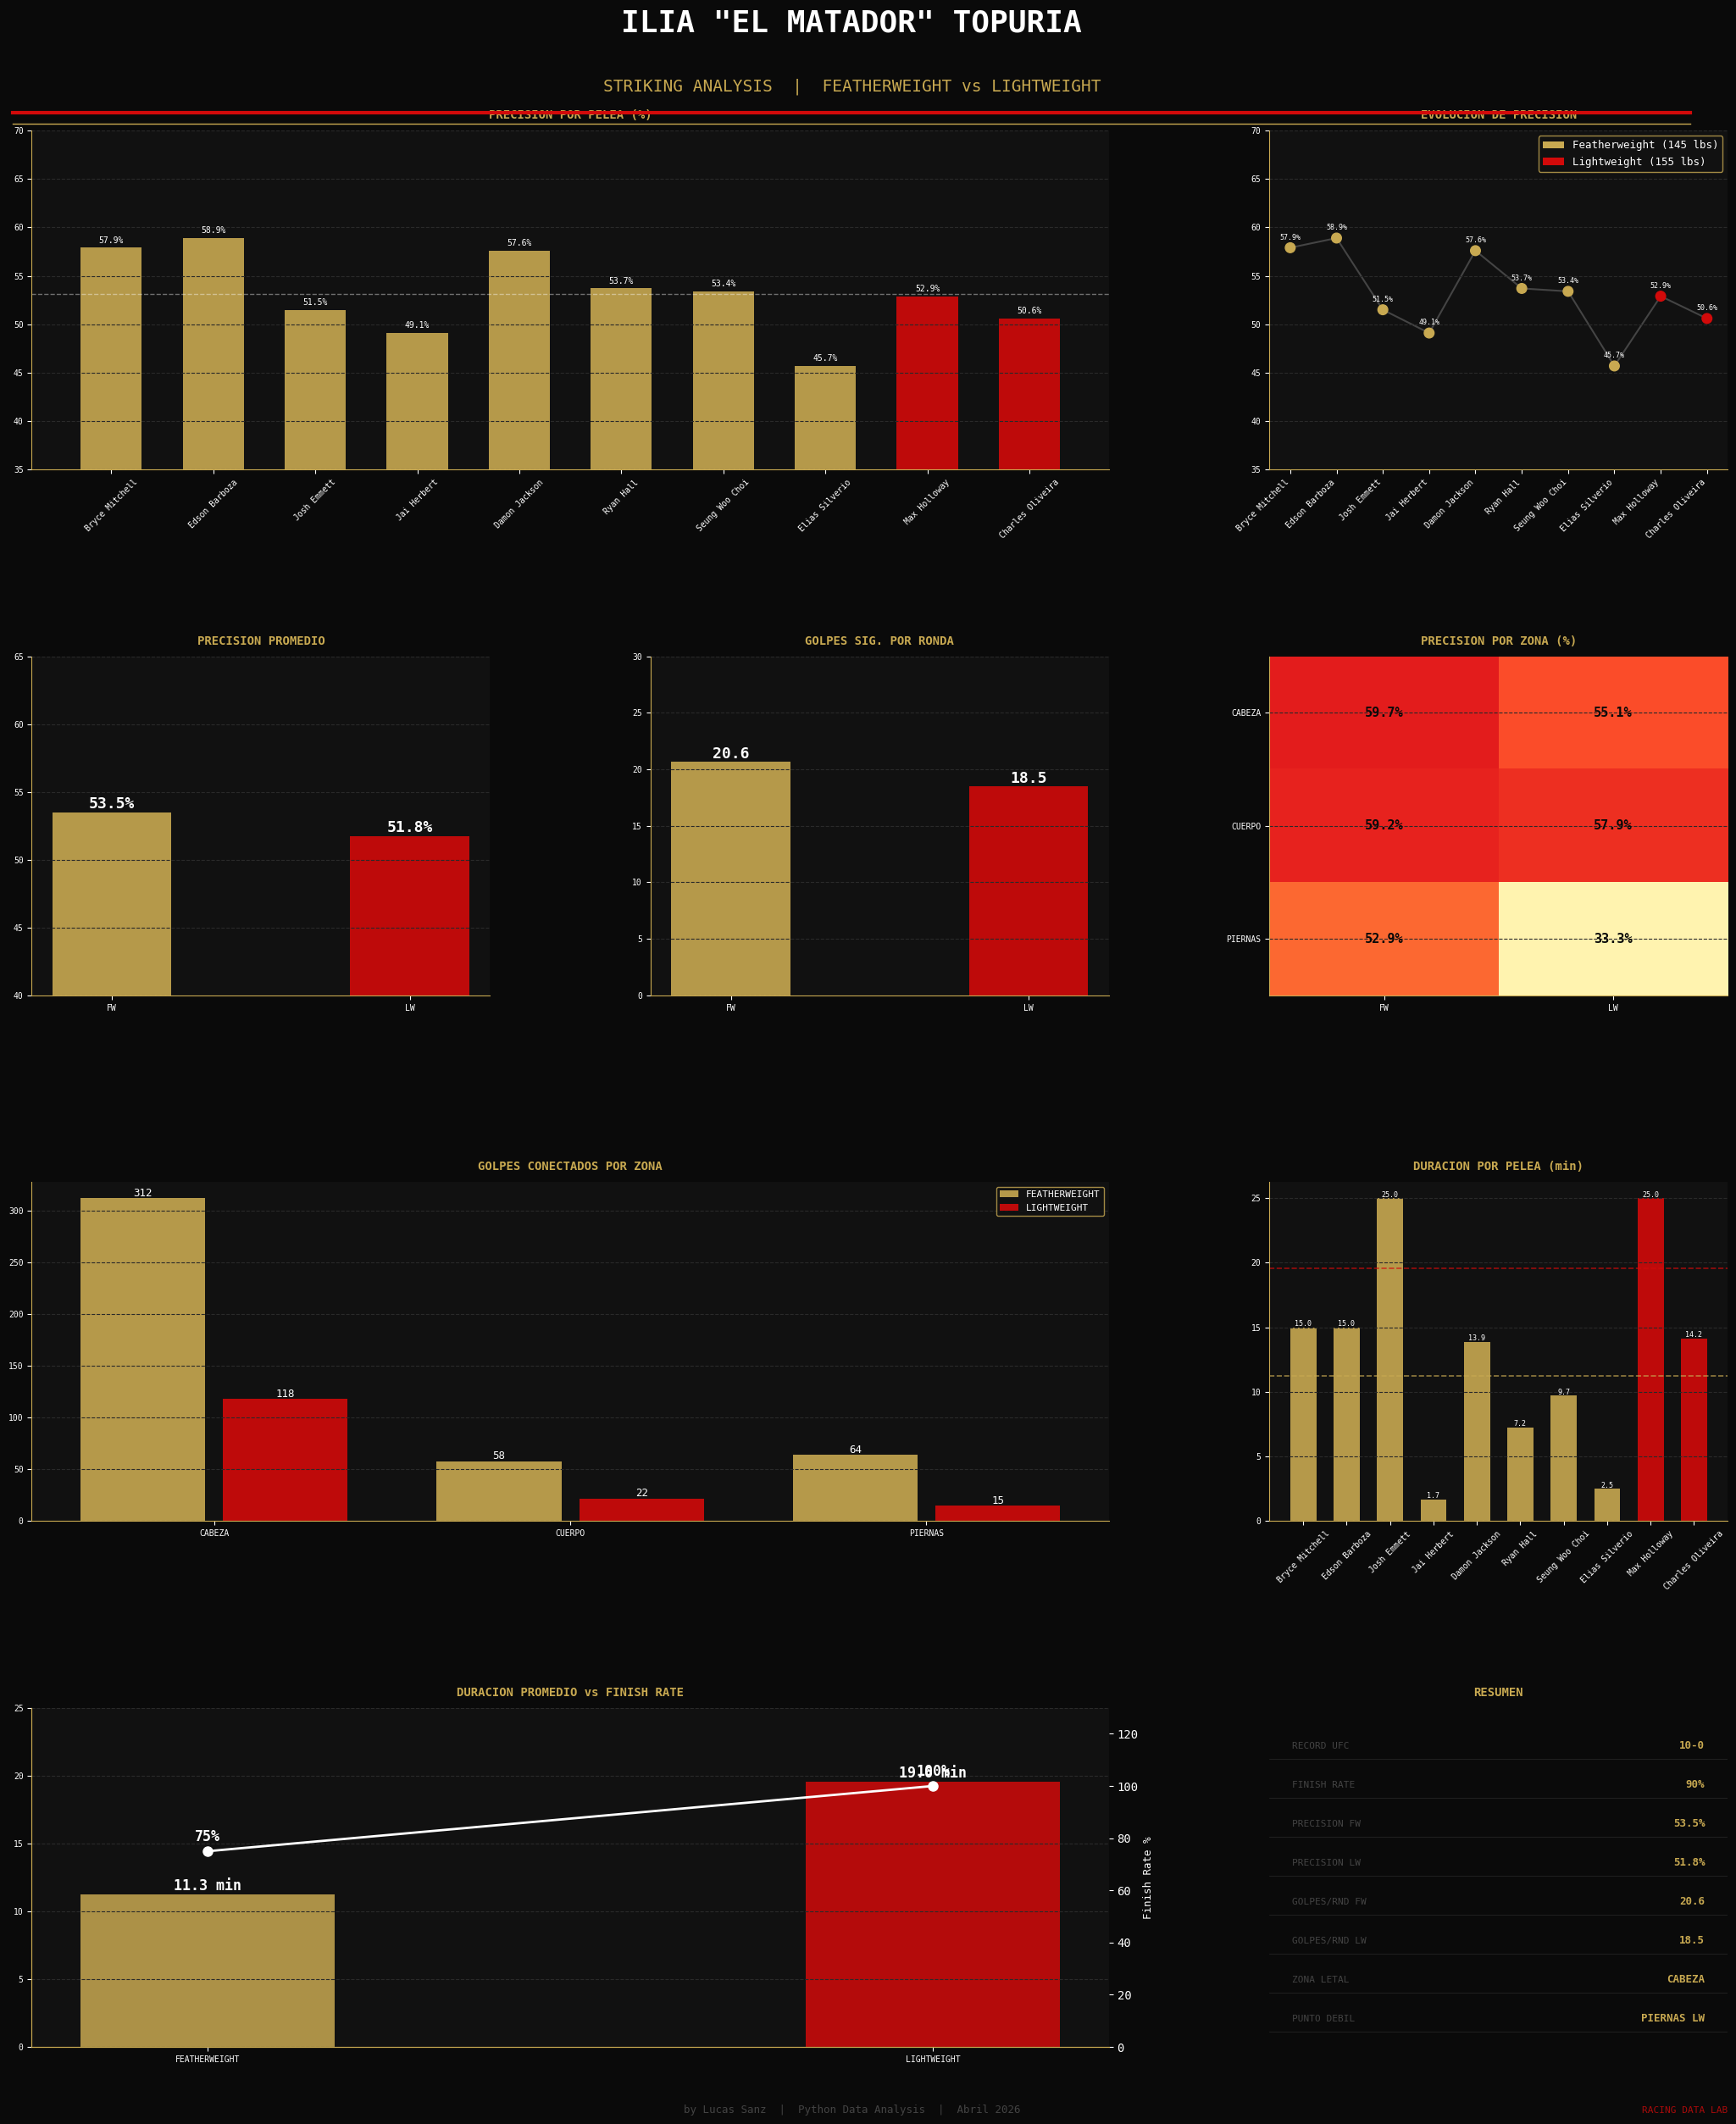

✅ Guardado: topuria_UFC_DEFINITIVO.png


In [32]:
# ============================================
# POSTER UFC DEFINITIVO - TODO EN UNA CELDA
# ============================================

UFC_BLACK  = "#0a0a0a"
UFC_RED    = "#D20A0A"
UFC_GOLD   = "#C8A951"
UFC_WHITE  = "#FFFFFF"
UFC_GRAY   = "#444444"
UFC_FW     = "#C8A951"
UFC_LW     = "#D20A0A"

plt.rcParams.update({
    "figure.facecolor":  UFC_BLACK,
    "axes.facecolor":    "#111111",
    "axes.edgecolor":    UFC_GOLD,
    "axes.labelcolor":   UFC_WHITE,
    "xtick.color":       UFC_WHITE,
    "ytick.color":       UFC_WHITE,
    "text.color":        UFC_WHITE,
    "grid.color":        "#2a2a2a",
    "grid.linestyle":    "--",
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

colores_pelea = [UFC_FW]*8 + [UFC_LW]*2

fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor(UFC_BLACK)

# Grid: 4 filas x 3 columnas
from matplotlib.gridspec import GridSpec
gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35,
              top=0.91, bottom=0.04, left=0.06, right=0.97)

# ── Encabezado ──────────────────────────────
fig.text(0.5, 0.955, 'ILIA "EL MATADOR" TOPURIA',
         ha="center", fontsize=26, fontweight="bold", color=UFC_WHITE, fontfamily="monospace")
fig.text(0.5, 0.928, "STRIKING ANALYSIS  |  FEATHERWEIGHT vs LIGHTWEIGHT",
         ha="center", fontsize=14, color=UFC_GOLD, fontfamily="monospace")
fig.add_artist(plt.Line2D([0.05,0.95],[0.918,0.918], color=UFC_RED,  linewidth=3, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.05,0.95],[0.913,0.913], color=UFC_GOLD, linewidth=1, transform=fig.transFigure))

def style_ax(ax, title):
    ax.set_facecolor("#111111")
    ax.set_title(title, color=UFC_GOLD, fontsize=10, fontweight="bold", fontfamily="monospace", pad=10)
    ax.spines["bottom"].set_color(UFC_GOLD)
    ax.spines["left"].set_color(UFC_GOLD)
    ax.yaxis.grid(True, color="#2a2a2a", linestyle="--")
    ax.tick_params(colors=UFC_WHITE, labelsize=7)

# ── G1: Precision por pelea (fila 0, col 0-1) ──
ax1 = fig.add_subplot(gs[0, 0:2])
bars = ax1.bar(df["rival"], df["sig_str_pct"], color=colores_pelea, alpha=0.9, width=0.6)
ax1.axhline(df["sig_str_pct"].mean(), color=UFC_WHITE, linestyle="--", linewidth=1, alpha=0.4)
ax1.set_ylim(35, 70)
style_ax(ax1, "PRECISION POR PELEA (%)")
ax1.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, df["sig_str_pct"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{val}%", ha="center", fontsize=7, color=UFC_WHITE)

# ── G2: Evolucion (fila 0, col 2) ──
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(range(len(df)), df["sig_str_pct"], color=UFC_GRAY, linewidth=1.5, zorder=1)
ax2.scatter(range(len(df)), df["sig_str_pct"], color=colores_pelea, s=70, zorder=2)
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(df["rival"], rotation=45, ha="right")
ax2.set_ylim(35, 70)
style_ax(ax2, "EVOLUCION DE PRECISION")
for i, val in enumerate(df["sig_str_pct"]):
    ax2.annotate(f"{val}%", (i, val), textcoords="offset points",
                 xytext=(0,7), ha="center", fontsize=6, color=UFC_WHITE)

# ── G3: Precision promedio (fila 1, col 0) ──
ax3 = fig.add_subplot(gs[1, 0])
prom_cat = df.groupby("categoria")["sig_str_pct"].mean()
bars3 = ax3.bar(["FW","LW"], prom_cat.values, color=[UFC_FW,UFC_LW], alpha=0.9, width=0.4)
ax3.set_ylim(40, 65)
style_ax(ax3, "PRECISION PROMEDIO")
for bar, val in zip(bars3, prom_cat.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold", color=UFC_WHITE)

# ── G4: Golpes por ronda (fila 1, col 1) ──
ax4 = fig.add_subplot(gs[1, 1])
prom_ronda = df.groupby("categoria")["sig_str_por_ronda"].mean()
bars4 = ax4.bar(["FW","LW"], prom_ronda.values, color=[UFC_FW,UFC_LW], alpha=0.9, width=0.4)
ax4.set_ylim(0, 30)
style_ax(ax4, "GOLPES SIG. POR RONDA")
for bar, val in zip(bars4, prom_ronda.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}", ha="center", fontsize=13, fontweight="bold", color=UFC_WHITE)

# ── G5: Heatmap zonas (fila 1, col 2) ──
ax5 = fig.add_subplot(gs[1, 2])
heatmap_data = np.array([[59.7,55.1],[59.2,57.9],[52.9,33.3]])
im = ax5.imshow(heatmap_data, cmap="YlOrRd", aspect="auto", vmin=30, vmax=70)
ax5.set_xticks([0,1]); ax5.set_xticklabels(["FW","LW"], fontsize=9)
ax5.set_yticks([0,1,2]); ax5.set_yticklabels(["CABEZA","CUERPO","PIERNAS"], fontsize=8)
style_ax(ax5, "PRECISION POR ZONA (%)")
for i in range(3):
    for j in range(2):
        ax5.text(j, i, f"{heatmap_data[i,j]}%", ha="center", va="center",
                 fontsize=11, fontweight="bold", color=UFC_BLACK)

# ── G6: Golpes por zona (fila 2, col 0-1) ──
ax6 = fig.add_subplot(gs[2, 0:2])
x = np.arange(3)
b1 = ax6.bar(x-0.2, [312,58,64], 0.35, label="FEATHERWEIGHT", color=UFC_FW, alpha=0.9)
b2 = ax6.bar(x+0.2, [118,22,15], 0.35, label="LIGHTWEIGHT",   color=UFC_LW, alpha=0.9)
ax6.set_xticks(x); ax6.set_xticklabels(["CABEZA","CUERPO","PIERNAS"], fontsize=9)
style_ax(ax6, "GOLPES CONECTADOS POR ZONA")
ax6.legend(fontsize=8, facecolor="#111111", edgecolor=UFC_GOLD, labelcolor=UFC_WHITE)
for bar in list(b1)+list(b2):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(int(bar.get_height())), ha="center", fontsize=9, color=UFC_WHITE)

# ── G7: Duracion por pelea (fila 2, col 2) ──
ax7 = fig.add_subplot(gs[2, 2])
bars7 = ax7.bar(df["rival"], df["duracion_min"], color=colores_pelea, alpha=0.9, width=0.6)
prom_fw = df[df["categoria"]=="Featherweight"]["duracion_min"].mean()
prom_lw = df[df["categoria"]=="Lightweight"]["duracion_min"].mean()
ax7.axhline(prom_fw, color=UFC_FW, linestyle="--", linewidth=1.2, alpha=0.7)
ax7.axhline(prom_lw, color=UFC_LW, linestyle="--", linewidth=1.2, alpha=0.7)
style_ax(ax7, "DURACION POR PELEA (min)")
ax7.tick_params(axis="x", rotation=45)
for bar, val in zip(bars7, df["duracion_min"]):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{val:.1f}", ha="center", fontsize=6, color=UFC_WHITE)

# ── G8: Duracion promedio + Finish Rate (fila 3, col 0-2) ──
ax8 = fig.add_subplot(gs[3, 0:2])
ax8b = ax8.twinx()
b = ax8.bar(["FEATHERWEIGHT","LIGHTWEIGHT"], [prom_fw, prom_lw],
            color=[UFC_FW,UFC_LW], alpha=0.85, width=0.35)
ax8b.plot(["FEATHERWEIGHT","LIGHTWEIGHT"], [75,100], color=UFC_WHITE,
          marker="o", linewidth=2, markersize=8)
ax8b.set_ylabel("Finish Rate %", color=UFC_WHITE, fontsize=9)
ax8b.tick_params(colors=UFC_WHITE)
ax8b.set_ylim(0,130)
ax8b.spines["right"].set_color(UFC_GOLD)
style_ax(ax8, "DURACION PROMEDIO vs FINISH RATE")
ax8.set_ylim(0, 25)
for bar, val in zip(b, [prom_fw, prom_lw]):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f} min", ha="center", fontsize=12, fontweight="bold", color=UFC_WHITE)
for i, val in enumerate([75,100]):
    ax8b.text(i, val+4, f"{val}%", ha="center", fontsize=12,
              fontweight="bold", color=UFC_WHITE)

# ── Stats resumen (fila 3, col 2) ──
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor("#111111")
ax9.axis("off")
ax9.set_title("RESUMEN", color=UFC_GOLD, fontsize=10, fontweight="bold", fontfamily="monospace", pad=10)
resumen_texto = [
    ("RECORD UFC",        "10-0"),
    ("FINISH RATE",       "90%"),
    ("PRECISION FW",      "53.5%"),
    ("PRECISION LW",      "51.8%"),
    ("GOLPES/RND FW",     "20.6"),
    ("GOLPES/RND LW",     "18.5"),
    ("ZONA LETAL",        "CABEZA"),
    ("PUNTO DEBIL",       "PIERNAS LW"),
]
for i, (label, valor) in enumerate(resumen_texto):
    ax9.text(0.05, 0.88 - i*0.115, label, fontsize=8, color=UFC_GRAY,
             fontfamily="monospace", transform=ax9.transAxes)
    ax9.text(0.95, 0.88 - i*0.115, valor, fontsize=9, color=UFC_GOLD,
             fontweight="bold", fontfamily="monospace", ha="right", transform=ax9.transAxes)
    ax9.plot([0, 1], [0.85 - i*0.115, 0.85 - i*0.115], color="#2a2a2a", 
         linewidth=0.5, transform=ax9.transAxes)

# ── Leyenda + Footer ──
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=UFC_FW, label="Featherweight (145 lbs)"),
                   Patch(facecolor=UFC_LW, label="Lightweight (155 lbs)")]
fig.legend(handles=legend_elements, loc="upper right", fontsize=9,
           facecolor="#111111", edgecolor=UFC_GOLD, labelcolor=UFC_WHITE,
           bbox_to_anchor=(0.97, 0.91))
fig.text(0.5, 0.01, "by Lucas Sanz  |  Python Data Analysis  |  Abril 2026",
         ha="center", fontsize=9, color=UFC_GRAY, fontfamily="monospace")
fig.text(0.97, 0.01, "RACING DATA LAB", ha="right", fontsize=8,
         color=UFC_RED, alpha=0.8, fontfamily="monospace")

plt.savefig("topuria_UFC_DEFINITIVO.png", dpi=180, bbox_inches="tight", facecolor=UFC_BLACK)
plt.show()
print("✅ Guardado: topuria_UFC_DEFINITIVO.png")

In [33]:
html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Ilia Topuria - Striking Analysis | Racing Data Lab</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{
            background-color: #0a0a0a;
            color: #ffffff;
            font-family: 'Courier New', monospace;
        }}

        /* HEADER */
        .header {{
            text-align: center;
            padding: 40px 20px 20px;
            border-bottom: 3px solid #D20A0A;
        }}
        .header h1 {{
            font-size: 2.8em;
            color: #ffffff;
            letter-spacing: 4px;
            text-transform: uppercase;
        }}
        .header h2 {{
            font-size: 1.1em;
            color: #C8A951;
            letter-spacing: 3px;
            margin-top: 8px;
        }}
        .header .line-gold {{
            height: 1px;
            background: #C8A951;
            margin: 10px auto;
            width: 80%;
        }}
        .header p {{
            color: #555;
            font-size: 0.85em;
            margin-top: 8px;
        }}

        /* STATS BANNER */
        .stats-banner {{
            display: flex;
            justify-content: center;
            gap: 0;
            background: #111111;
            border-top: 1px solid #C8A951;
            border-bottom: 1px solid #C8A951;
            margin: 30px 0;
        }}
        .stat-item {{
            text-align: center;
            padding: 20px 40px;
            border-right: 1px solid #2a2a2a;
        }}
        .stat-item:last-child {{ border-right: none; }}
        .stat-value {{
            font-size: 2em;
            font-weight: bold;
            color: #C8A951;
        }}
        .stat-label {{
            font-size: 0.75em;
            color: #888;
            margin-top: 4px;
            letter-spacing: 2px;
        }}

        /* SECTION */
        .section {{
            max-width: 1100px;
            margin: 40px auto;
            padding: 0 20px;
        }}
        .section-title {{
            font-size: 1em;
            color: #C8A951;
            letter-spacing: 3px;
            border-left: 4px solid #D20A0A;
            padding-left: 12px;
            margin-bottom: 20px;
        }}

        /* TABLA */
        table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 0.9em;
        }}
        th {{
            background: #1a1a1a;
            color: #C8A951;
            padding: 12px;
            text-align: center;
            border-bottom: 2px solid #D20A0A;
            letter-spacing: 1px;
        }}
        td {{
            padding: 10px 12px;
            text-align: center;
            border-bottom: 1px solid #1f1f1f;
            color: #ffffff;
        }}
        tr:hover {{ background: #151515; }}
        .fw {{ color: #C8A951; font-weight: bold; }}
        .lw {{ color: #D20A0A; font-weight: bold; }}

        /* CARDS */
        .cards {{
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 20px;
            margin-top: 20px;
        }}
        .card {{
            background: #111111;
            border: 1px solid #2a2a2a;
            border-top: 3px solid #C8A951;
            padding: 20px;
            text-align: center;
        }}
        .card.lw-card {{ border-top-color: #D20A0A; }}
        .card-value {{
            font-size: 2.2em;
            font-weight: bold;
            color: #C8A951;
        }}
        .card.lw-card .card-value {{ color: #D20A0A; }}
        .card-label {{
            font-size: 0.75em;
            color: #888;
            margin-top: 6px;
            letter-spacing: 2px;
        }}
        .card-cat {{
            font-size: 0.7em;
            color: #444;
            margin-top: 4px;
        }}

        /* IMAGEN */
        .poster {{
            text-align: center;
            margin: 40px auto;
            max-width: 1100px;
            padding: 0 20px;
        }}
        .poster img {{
            width: 100%;
            border: 1px solid #2a2a2a;
        }}

        /* CONCLUSIONES */
        .conclusiones {{
            background: #111111;
            border-left: 4px solid #D20A0A;
            padding: 24px;
            margin-top: 20px;
        }}
        .conclusiones p {{
            color: #cccccc;
            line-height: 1.8;
            font-size: 0.92em;
        }}
        .conclusiones strong {{ color: #C8A951; }}

        /* FOOTER */
        .footer {{
            text-align: center;
            padding: 30px;
            border-top: 1px solid #1a1a1a;
            color: #333;
            font-size: 0.8em;
            margin-top: 60px;
        }}
        .footer span {{ color: #D20A0A; }}
    </style>
</head>
<body>

<!-- HEADER -->
<div class="header">
    <h1>Ilia "El Matador" Topuria</h1>
    <h2>Striking Analysis | Featherweight vs Lightweight</h2>
    <div class="line-gold"></div>
    <p>by Lucas Sanz &nbsp;|&nbsp; Python Data Analysis &nbsp;|&nbsp; Abril 2026</p>
</div>

<!-- STATS BANNER -->
<div class="stats-banner">
    <div class="stat-item">
        <div class="stat-value">10-0</div>
        <div class="stat-label">RECORD UFC</div>
    </div>
    <div class="stat-item">
        <div class="stat-value">53.5%</div>
        <div class="stat-label">PRECISION FW</div>
    </div>
    <div class="stat-item">
        <div class="stat-value">51.8%</div>
        <div class="stat-label">PRECISION LW</div>
    </div>
    <div class="stat-item">
        <div class="stat-value">90%</div>
        <div class="stat-label">FINISH RATE</div>
    </div>
    <div class="stat-item">
        <div class="stat-value">20.6</div>
        <div class="stat-label">GOLPES/RND FW</div>
    </div>
    <div class="stat-item">
        <div class="stat-value">18.5</div>
        <div class="stat-label">GOLPES/RND LW</div>
    </div>
</div>

<!-- POSTER -->
<div class="poster">
    <p class="section-title">ANALISIS COMPLETO</p>
    <img src="topuria_UFC_DEFINITIVO.png" alt="Topuria Striking Analysis">
</div>

<!-- TABLA -->
<div class="section">
    <p class="section-title">ESTADISTICAS POR PELEA</p>
    <table>
        <tr>
            <th>RIVAL</th>
            <th>CATEGORIA</th>
            <th>SIG. STRIKES</th>
            <th>INTENTADOS</th>
            <th>PRECISION</th>
            <th>GOLPES/RND</th>
            <th>DURACION</th>
        </tr>
        {''.join([
            f"<tr><td>{row['rival']}</td>"
            f"<td class='{'fw' if row['categoria']=='Featherweight' else 'lw'}'>"
            f"{'FW' if row['categoria']=='Featherweight' else 'LW'}</td>"
            f"<td>{row['sig_str_land']}</td>"
            f"<td>{row['sig_str_att']}</td>"
            f"<td><strong>{row['sig_str_pct']}%</strong></td>"
            f"<td>{row['sig_str_por_ronda']}</td>"
            f"<td>{row['duracion_min']} min</td></tr>"
            for _, row in df.iterrows()
        ])}
    </table>
</div>

<!-- CARDS -->
<div class="section">
    <p class="section-title">COMPARATIVA POR CATEGORIA</p>
    <div class="cards">
        <div class="card">
            <div class="card-value">53.5%</div>
            <div class="card-label">PRECISION</div>
            <div class="card-cat">FEATHERWEIGHT</div>
        </div>
        <div class="card lw-card">
            <div class="card-value">51.8%</div>
            <div class="card-label">PRECISION</div>
            <div class="card-cat">LIGHTWEIGHT</div>
        </div>
        <div class="card">
            <div class="card-value">-1.7%</div>
            <div class="card-label">DIFERENCIA</div>
            <div class="card-cat">AL SUBIR DE CATEGORIA</div>
        </div>
        <div class="card">
            <div class="card-value">20.6</div>
            <div class="card-label">GOLPES / RONDA</div>
            <div class="card-cat">FEATHERWEIGHT</div>
        </div>
        <div class="card lw-card">
            <div class="card-value">18.5</div>
            <div class="card-label">GOLPES / RONDA</div>
            <div class="card-cat">LIGHTWEIGHT</div>
        </div>
        <div class="card">
            <div class="card-value">11.3'</div>
            <div class="card-label">DURACION PROM.</div>
            <div class="card-cat">FEATHERWEIGHT</div>
        </div>
    </div>
</div>

<!-- CONCLUSIONES -->
<div class="section">
    <p class="section-title">CONCLUSION</p>
    <div class="conclusiones">
        <p>
            Topuria subio a Lightweight y sus numeros <strong>apenas cambiaron</strong>. 
            Con una caida de solo <strong>1.7% en precision</strong> enfrentando a 
            <strong>Max Holloway y Charles Oliveira</strong> — dos de los mejores en la historia de sus divisiones —
            los datos confirman que su boxeo tecnico y preciso <strong>trasciende las categorias de peso</strong>.
            <br><br>
            Su zona mas letal sigue siendo la <strong>cabeza (55-59%)</strong>, 
            mientras que las piernas representan su unico punto debil al subir de division <strong>(33.3% en LW)</strong>.
            Con un <strong>finish rate del 90%</strong>, El Matador no solo golpea con precision — golpea para terminar.
        </p>
    </div>
</div>

<!-- FOOTER -->
<div class="footer">
    by Lucas Sanz &nbsp;|&nbsp; Python Data Analysis &nbsp;|&nbsp; Abril 2026
    &nbsp;&nbsp;—&nbsp;&nbsp;
    <span>RACING DATA LAB</span>
</div>

</body>
</html>
"""

with open("topuria_analysis.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("✅ Guardado: topuria_analysis.html")
print("📌 Subilo a GitHub junto con topuria_UFC_DEFINITIVO.png")
print("📌 Activá GitHub Pages y compartí el link en LinkedIn")

✅ Guardado: topuria_analysis.html
📌 Subilo a GitHub junto con topuria_UFC_DEFINITIVO.png
📌 Activá GitHub Pages y compartí el link en LinkedIn
